In [14]:
import re
import time
import joblib
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed
from scipy.ndimage import distance_transform_edt
from tqdm.auto import tqdm

from scalesurfer.config import DATA_PATH, MODULE_PATH, SEED
from scalesurfer.data import build_label_lut, default_aparc_aseg_label_values
from scalesurfer.experiments import build_v8_split_from_root
from scalesurfer.metrics import dense_labels_to_fs_ids
from scalesurfer import ScaleSurfer

In [15]:
FS_STATS_CACHE = Path("/home/rph/scalesurfer/data/fs8_freesurfer_stats_cache")
SUBJECTS_DIR = DATA_PATH / "subjects_dir"

In [16]:
from scalesurfer.config import DATA_PATH
from scalesurfer.splits import (
    DEFAULT_NOTEBOOK_SPLIT_MANIFEST_PATH,
    build_or_load_study_split_manifest,
    discover_training_pairs,
    extract_study_id,
    split_from_manifest,
)
file_map = discover_training_pairs(
    DATA_PATH / "tensors",
    x_filename="orig.pt",
    y_filename="aparc+aseg.pt",
)
ds = [i.split("/")[0] for i in list(file_map.keys())]

In [17]:
from glob import glob
ds = glob("/home/rph/scalesurfer/docs/notebooks/03_inference/fs8/*/rawavg.mgz")
ds = {i[54:62]: i for i in ds[:100]}

In [18]:
# images
images = list(ds.values())

# names of the output dirs in subject_dir
subjects = list(ds.keys())

In [19]:
# initialize object
surfer = ScaleSurfer(
    images,
    subjects,
    SUBJECTS_DIR,
    batch_size=1,
    n_jobs_cpu=-1,
    device="cuda",
    conform_backend="nibabel",
    overwrite=True,
    volume_dtype="float32"
)

# surfer.prepare_images()   # saves subject_dir/*/mri/orig.{pt, mgz}
# surfer.predict_volumes(batch_size=5, volume_dtype="float16", patch_chunk_size=128, write=True)

In [20]:
DK_APARC_NAMES = [
    "unknown",
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "corpuscallosum",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]
DK_NAME_TO_INDEX = {name: idx for idx, name in enumerate(DK_APARC_NAMES)}
CLASS_VALUES, _ = build_label_lut(default_aparc_aseg_label_values())


def normalize_aparc_name(name):
    name = str(name).strip().lower()
    name = re.sub(r'^ctx[-_](lh|rh)[-_.]', '', name)
    name = re.sub(r'^(lh|rh)[-_.]', '', name)
    return name


def aparc_region_key(hemi, name):
    return f"{hemi}:{normalize_aparc_name(name)}"


def aparc_fs_id(hemi, name):
    name = normalize_aparc_name(name)
    if name not in DK_NAME_TO_INDEX:
        return pd.NA
    return (1000 if hemi == "lh" else 2000) + DK_NAME_TO_INDEX[name]


def _torch_load_cpu(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _as_3d_int_array(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    arr = np.squeeze(arr)
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D segmentation, got shape {arr.shape}")
    return np.rint(arr).astype(np.int32, copy=False)


def _is_cortex_id_array(x):
    x = np.asarray(x)
    return ((1000 <= x) & (x < 2000)) | ((2000 <= x) & (x < 3000))


def _describe_fs_id(fs_id):
    fs_id = int(fs_id)
    if 1000 <= fs_id < 2000:
        idx = fs_id - 1000
        name = DK_APARC_NAMES[idx] if idx < len(DK_APARC_NAMES) else f"ctx_lh_{idx}"
        return f"lh:{name}", "lh", name
    if 2000 <= fs_id < 3000:
        idx = fs_id - 2000
        name = DK_APARC_NAMES[idx] if idx < len(DK_APARC_NAMES) else f"ctx_rh_{idx}"
        return f"rh:{name}", "rh", name
    return f"aseg:{fs_id}", None, f"fs_{fs_id}"


def _bincount_add(target, values, face_area):
    values = np.asarray(values).reshape(-1)
    if values.size == 0:
        return
    values = values[values > 0]
    if values.size:
        target += np.bincount(values, minlength=target.size)[: target.size] * face_area


def _boundary_areas_by_label(labels, voxel_sizes):
    max_label = int(labels.max()) if labels.size else 0
    all_boundary_area = np.zeros(max_label + 1, dtype=np.float64)
    cortex_to_noncortex_area = np.zeros(max_label + 1, dtype=np.float64)
    face_areas = (
        float(voxel_sizes[1] * voxel_sizes[2]),
        float(voxel_sizes[0] * voxel_sizes[2]),
        float(voxel_sizes[0] * voxel_sizes[1]),
    )

    for axis, face_area in enumerate(face_areas):
        lower = np.take(labels, 0, axis=axis)
        upper = np.take(labels, -1, axis=axis)
        _bincount_add(all_boundary_area, lower, face_area)
        _bincount_add(all_boundary_area, upper, face_area)
        _bincount_add(cortex_to_noncortex_area, lower[_is_cortex_id_array(lower)], face_area)
        _bincount_add(cortex_to_noncortex_area, upper[_is_cortex_id_array(upper)], face_area)

        lo_sl = [slice(None)] * 3
        hi_sl = [slice(None)] * 3
        lo_sl[axis] = slice(None, -1)
        hi_sl[axis] = slice(1, None)
        lo = labels[tuple(lo_sl)]
        hi = labels[tuple(hi_sl)]
        diff = lo != hi
        if not np.any(diff):
            continue

        lo_vals = lo[diff]
        hi_vals = hi[diff]
        lo_is_cortex = _is_cortex_id_array(lo_vals)
        hi_is_cortex = _is_cortex_id_array(hi_vals)
        _bincount_add(all_boundary_area, lo_vals, face_area)
        _bincount_add(all_boundary_area, hi_vals, face_area)
        _bincount_add(cortex_to_noncortex_area, lo_vals[lo_is_cortex & ~hi_is_cortex], face_area)
        _bincount_add(cortex_to_noncortex_area, hi_vals[hi_is_cortex & ~lo_is_cortex], face_area)

    return all_boundary_area, cortex_to_noncortex_area


def load_predicted_fs_labels(subject, subject_dir):
    dense = _torch_load_cpu(Path(subject_dir) / subject / "mri" / "aparc+aseg.pt")
    dense_arr = _as_3d_int_array(dense)
    max_label = int(dense_arr.max()) if dense_arr.size else 0
    if max_label <= len(CLASS_VALUES) - 1:
        fs_labels = dense_labels_to_fs_ids(dense, class_values=CLASS_VALUES)
        return _as_3d_int_array(fs_labels)
    return dense_arr


def fast_aparc_aseg_features(subject, subject_dir):
    mri_dir = Path(subject_dir) / subject / "mri"
    labels = load_predicted_fs_labels(subject, subject_dir)
    orig_img = nib.as_closest_canonical(nib.load(str(mri_dir / "orig.mgz")))
    voxel_sizes = np.sqrt((orig_img.affine[:3, :3] ** 2).sum(axis=0))
    voxel_volume = float(np.prod(voxel_sizes))

    max_label = int(labels.max()) if labels.size else 0
    counts = np.bincount(labels.reshape(-1), minlength=max_label + 1)
    region_ids = np.flatnonzero(counts > 0)
    region_ids = region_ids[region_ids != 0]

    all_boundary_area, cortex_to_noncortex_area = _boundary_areas_by_label(labels, voxel_sizes)
    voxel_count = counts[region_ids].astype(np.int64)
    volume_mm3 = voxel_count * voxel_volume
    all_area_mm2 = all_boundary_area[region_ids]
    cortical_area_proxy_mm2 = cortex_to_noncortex_area[region_ids] / 2.0
    is_cortex = _is_cortex_id_array(region_ids)

    # aparc+aseg has no white/pial surfaces. For cortex, use half of the
    # cortex-to-noncortex boundary as a pial/white mean area proxy, and V/A as
    # a very fast thickness proxy.
    surface_area_mm2 = np.where(
        is_cortex & (cortical_area_proxy_mm2 > 0),
        cortical_area_proxy_mm2,
        all_area_mm2,
    )
    thickness_proxy_mm = np.divide(
        volume_mm3,
        surface_area_mm2,
        out=np.full_like(volume_mm3, np.nan, dtype=np.float64),
        where=surface_area_mm2 > 0,
    )

    cortex_mask = _is_cortex_id_array(labels)
    cortex_distance_mm = distance_transform_edt(cortex_mask, sampling=voxel_sizes)
    cortex_distance_mm = np.maximum(cortex_distance_mm - 0.5 * float(np.min(voxel_sizes)), 0.0)
    distance_sum_mm = np.bincount(
        labels.reshape(-1),
        weights=cortex_distance_mm.reshape(-1),
        minlength=max_label + 1,
    )[region_ids]
    mean_cortex_distance_mm = np.divide(
        distance_sum_mm,
        voxel_count,
        out=np.full_like(volume_mm3, np.nan, dtype=np.float64),
        where=is_cortex & (voxel_count > 0),
    )
    thickness_width_mm = 4.0 * mean_cortex_distance_mm
    equivalent_diameter_mm = np.divide(
        6.0 * volume_mm3,
        all_area_mm2,
        out=np.full_like(volume_mm3, np.nan, dtype=np.float64),
        where=all_area_mm2 > 0,
    )
    compactness = np.divide(
        surface_area_mm2**3,
        36.0 * np.pi * volume_mm3**2,
        out=np.full_like(volume_mm3, np.nan, dtype=np.float64),
        where=volume_mm3 > 0,
    )

    descriptions = [_describe_fs_id(fs_id) for fs_id in region_ids]
    return pd.DataFrame(
        {
            "subject": subject,
            "fs_id": region_ids.astype(np.int32),
            "region_key": [d[0] for d in descriptions],
            "hemi": [d[1] for d in descriptions],
            "region_name": [d[2] for d in descriptions],
            "is_cortex": is_cortex,
            "voxel_count": voxel_count,
            "volume_mm3": volume_mm3,
            "surface_area_mm2": surface_area_mm2,
            "boundary_area_all_mm2": all_area_mm2,
            "cortex_boundary_area_mm2": cortex_to_noncortex_area[region_ids],
            "thickness_proxy_mm": thickness_proxy_mm,
            "mean_cortex_distance_mm": mean_cortex_distance_mm,
            "thickness_width_mm": thickness_width_mm,
            "equivalent_diameter_mm": equivalent_diameter_mm,
            "compactness": compactness,
        }
    )


In [21]:
@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


N_FEATURE_JOBS = -1

t0 = time.perf_counter()
with tqdm_joblib(tqdm(total=len(subjects), desc="Extracting aparc+aseg features")):
    feature_frames = Parallel(n_jobs=N_FEATURE_JOBS, prefer="processes", batch_size=1)(
        delayed(fast_aparc_aseg_features)(subject, SUBJECTS_DIR)
        for subject in subjects
    )
pred_features = pd.concat(feature_frames, ignore_index=True)
print(f"extracted {len(pred_features):,} per-region feature rows in {time.perf_counter() - t0:.2f}s")
pred_features.sort_values(["subject", "fs_id"]).head(20)


Extracting aparc+aseg features:   0%|          | 0/100 [00:00<?, ?it/s]

extracted 10,315 per-region feature rows in 99.57s


,subject,fs_id,region_key,hemi,region_name,is_cortex,voxel_count,volume_mm3,surface_area_mm2,boundary_area_all_mm2,cortex_boundary_area_mm2,thickness_proxy_mm,mean_cortex_distance_mm,thickness_width_mm,equivalent_diameter_mm,compactness
4948,ds000009,2,aseg:2,NaN,fs_2,False,174503,174502.995588,116691.998053,116691.998053,0.0,1.495415,NaN,NaN,8.972492,461.386711
4949,ds000009,4,aseg:4,NaN,fs_4,False,7073,7072.999821,5541.999909,5541.999909,0.0,1.276254,NaN,NaN,7.657524,30.084298
4950,ds000009,5,aseg:5,NaN,fs_5,False,169,168.999996,497.999992,497.999992,0.0,0.339357,NaN,NaN,2.036145,38.235101
4951,ds000009,7,aseg:7,NaN,fs_7,False,10342,10341.999739,8281.999858,8281.999858,0.0,1.248732,NaN,NaN,7.492393,46.961746
4952,ds000009,8,aseg:8,NaN,fs_8,False,47306,47305.998804,21659.999630,21659.999630,0.0,2.184026,NaN,NaN,13.104155,40.150460
4953,ds000009,10,aseg:10,NaN,fs_10,False,6150,6149.999844,2927.999952,2927.999952,0.0,2.100410,NaN,NaN,12.602459,5.868277
4954,ds000009,11,aseg:11,NaN,fs_11,False,3644,3643.999908,2829.999955,2829.999955,0.0,1.287632,NaN,NaN,7.725795,15.092118
4955,ds000009,12,aseg:12,NaN,fs_12,False,5242,5241.999867,3167.999951,3167.999951,0.0,1.654672,NaN,NaN,9.928030,10.230789
4956,ds000009,13,aseg:13,NaN,fs_13,False,1511,1510.999962,1147.999982,1147.999982,0.0,1.316202,NaN,NaN,7.897212,5.859281
4957,ds000009,14,aseg:14,NaN,fs_14,False,572,571.999986,863.999987,863.999987,0.0,0.662037,NaN,NaN,3.972222,17.429976


In [22]:
pred_features.to_csv("_pred_features.csv")

In [23]:
TABLE_COL_RE = re.compile(r"#\s*TableCol\s+(\d+)\s+ColHeader\s+(\S+)")
CACHE_NAME_RE = re.compile(r"^(ds\d+)__(sub-[^_]+)__(ses-[^_]+)__")

def _cache_identity(subject, anat_file):
    text = str(anat_file)
    dataset_match = re.search(r"(ds\d+)", text)
    subject_match = re.search(r"(sub-[A-Za-z0-9]+)", text)
    session_match = re.search(r"(ses-[A-Za-z0-9]+)", text)
    return {
        "dataset": dataset_match.group(1) if dataset_match else None,
        "subject": subject_match.group(1) if subject_match else str(subject),
        "session": session_match.group(1) if session_match else "ses-none",
    }


def _cache_identity_from_name(cache_name):
    match = CACHE_NAME_RE.match(str(cache_name))
    if match is None:
        return None
    return {"dataset": match.group(1), "subject": match.group(2), "session": match.group(3)}


def find_stats_dir(subject, anat_file=None, cache_root=FS_STATS_CACHE):
    cache_root = Path(cache_root)
    direct = cache_root / str(subject) / "stats"
    if direct.exists():
        return direct
    if not cache_root.exists():
        return None

    query = _cache_identity(subject, anat_file or "")
    matches = []
    for stats_dir in cache_root.glob("*/stats"):
        identity = _cache_identity_from_name(stats_dir.parent.name)
        if identity is None:
            continue
        if identity["subject"] != query["subject"]:
            continue
        if query["session"] and identity["session"] != query["session"]:
            continue
        if query["dataset"] and identity["dataset"] != query["dataset"]:
            continue
        score = int(identity["dataset"] == query["dataset"]) + int(identity["session"] == query["session"])
        matches.append((score, stats_dir.parent.name, stats_dir))

    if not matches:
        return None
    matches.sort(key=lambda item: (-item[0], item[1]))
    return matches[0][2]


def read_freesurfer_stats_table(path):
    path = Path(path)
    col_headers = {}
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                match = TABLE_COL_RE.match(line)
                if match:
                    col_headers[int(match.group(1))] = match.group(2)
                continue
            rows.append(line.split())

    if not rows:
        return pd.DataFrame()
    if col_headers:
        columns = [col_headers[idx] for idx in sorted(col_headers)]
        width = min(len(columns), *(len(row) for row in rows))
        df = pd.DataFrame([row[:width] for row in rows], columns=columns[:width])
    else:
        df = pd.DataFrame(rows)

    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.notna().sum() == df[col].notna().sum():
            df[col] = numeric
    return df


def find_aparc_stats_path(stats_dir, hemi):
    exact = Path(stats_dir) / f"{hemi}.aparc.stats"
    if exact.exists():
        return exact

    candidates = sorted(Path(stats_dir).glob(f"{hemi}.*aparc*.stats"))
    for candidate in candidates:
        table = read_freesurfer_stats_table(candidate)
        if {"StructName", "SurfArea", "GrayVol", "ThickAvg"}.issubset(table.columns):
            names = table["StructName"].astype(str).map(normalize_aparc_name)
            if names.isin(DK_NAME_TO_INDEX).sum() > 0:
                return candidate
    return None


def freesurfer_subject_features(subject, stats_dir):
    stats_dir = Path(stats_dir)
    frames = []

    aseg_path = stats_dir / "aseg.stats"
    if aseg_path.exists():
        aseg = read_freesurfer_stats_table(aseg_path)
        if {"SegId", "Volume_mm3"}.issubset(aseg.columns):
            frames.append(
                pd.DataFrame(
                    {
                        "subject": subject,
                        "source": "aseg",
                        "fs_id": aseg["SegId"].astype("Int64"),
                        "region_key": "aseg:" + aseg["SegId"].astype(int).astype(str),
                        "fs_region_name": aseg.get("StructName", aseg["SegId"].astype(str)),
                        "fs_volume_mm3": pd.to_numeric(aseg["Volume_mm3"], errors="coerce"),
                        "fs_surface_area_mm2": np.nan,
                        "fs_thickness_mm": np.nan,
                        "fs_equivalent_diameter_mm": np.nan,
                        "fs_compactness": np.nan,
                    }
                )
            )

    for hemi, base_id in (("lh", 1000), ("rh", 2000)):
        aparc_path = find_aparc_stats_path(stats_dir, hemi)
        if aparc_path is None:
            continue
        aparc = read_freesurfer_stats_table(aparc_path)
        required = {"StructName", "SurfArea", "GrayVol", "ThickAvg"}
        if not required.issubset(aparc.columns):
            continue
        struct_names = aparc["StructName"].astype(str)
        fs_ids = [aparc_fs_id(hemi, name) for name in struct_names]
        fs_volume_mm3 = pd.to_numeric(aparc["GrayVol"], errors="coerce")
        fs_surface_area_mm2 = pd.to_numeric(aparc["SurfArea"], errors="coerce")
        fs_thickness_mm = pd.to_numeric(aparc["ThickAvg"], errors="coerce")
        fs_volume_values = fs_volume_mm3.to_numpy(dtype=np.float64)
        fs_surface_area_values = fs_surface_area_mm2.to_numpy(dtype=np.float64)
        fs_equivalent_diameter_mm = np.divide(
            6.0 * fs_volume_values,
            fs_surface_area_values,
            out=np.full(len(aparc), np.nan, dtype=np.float64),
            where=fs_surface_area_values > 0,
        )
        fs_compactness = np.divide(
            fs_surface_area_values**3,
            36.0 * np.pi * fs_volume_values**2,
            out=np.full(len(aparc), np.nan, dtype=np.float64),
            where=fs_volume_values > 0,
        )
        aparc_features = pd.DataFrame(
            {
                "subject": subject,
                "source": "aparc",
                "fs_id": pd.array(fs_ids, dtype="Int64"),
                "region_key": [aparc_region_key(hemi, name) for name in struct_names],
                "fs_region_name": struct_names,
                "fs_volume_mm3": fs_volume_mm3,
                "fs_surface_area_mm2": fs_surface_area_mm2,
                "fs_thickness_mm": fs_thickness_mm,
                "fs_equivalent_diameter_mm": fs_equivalent_diameter_mm,
                "fs_compactness": fs_compactness,
            }
        )
        aparc_features = aparc_features[aparc_features["fs_id"].notna()]
        if not aparc_features.empty:
            frames.append(aparc_features)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


In [24]:
LIKE_FOR_LIKE_SPECS = [
    {
        "source": "aseg",
        "measure": "volume",
        "pred_col": "volume_mm3",
        "pred_feature": "ScaleSurfer aseg volume",
        "fs_col": "fs_volume_mm3",
        "fs_feature": "FreeSurfer aseg volume",
    },
    {
        "source": "aparc",
        "measure": "volume",
        "pred_col": "volume_mm3",
        "pred_feature": "ScaleSurfer aparc gray volume",
        "fs_col": "fs_volume_mm3",
        "fs_feature": "FreeSurfer aparc GrayVol",
    },
    {
        "source": "aparc",
        "measure": "surface area",
        "pred_col": "surface_area_mm2",
        "pred_feature": "ScaleSurfer surface-area proxy",
        "fs_col": "fs_surface_area_mm2",
        "fs_feature": "FreeSurfer SurfArea",
    },
    {
        "source": "aparc",
        "measure": "thickness",
        "pred_col": "thickness_width_mm",
        "pred_feature": "ScaleSurfer cortex EDT width",
        "fs_col": "fs_thickness_mm",
        "fs_feature": "FreeSurfer ThickAvg",
    },
    {
        "source": "aparc",
        "measure": "equivalent diameter",
        "pred_col": "equivalent_diameter_mm",
        "pred_feature": "ScaleSurfer equivalent diameter proxy",
        "fs_col": "fs_equivalent_diameter_mm",
        "fs_feature": "FreeSurfer GrayVol/SurfArea equivalent diameter",
    },
    {
        "source": "aparc",
        "measure": "compactness",
        "pred_col": "compactness",
        "pred_feature": "ScaleSurfer compactness proxy",
        "fs_col": "fs_compactness",
        "fs_feature": "FreeSurfer compactness from GrayVol/SurfArea",
    },
]
REQUIRED_LIKE_FOR_LIKE_MEASURES = ("volume", "surface area", "thickness", "equivalent diameter", "compactness")
MEASURE_ORDER = {measure: idx for idx, measure in enumerate(REQUIRED_LIKE_FOR_LIKE_MEASURES)}


def _merge_predicted_and_freesurfer(pred_features, gt, fs_col):
    by_key = pred_features.merge(
        gt[["subject", "region_key", "source", "fs_region_name", fs_col]],
        on=["subject", "region_key"],
        how="inner",
    )
    if not by_key.empty:
        return by_key

    pred_id = pred_features[pred_features["fs_id"].notna()]
    gt_id = gt[gt["fs_id"].notna()]
    by_id = pred_id.merge(
        gt_id[["subject", "fs_id", "source", "region_key", "fs_region_name", fs_col]],
        on=["subject", "fs_id"],
        how="inner",
        suffixes=("", "_fs"),
    )
    if "region_key_fs" in by_id.columns:
        by_id["fs_region_key"] = by_id["region_key_fs"]
    return by_id


def _positive_log(values, floor=1e-6):
    values = pd.to_numeric(values, errors="coerce").to_numpy(dtype=np.float64)
    return np.log(np.clip(values, floor, None))


def _thickness_model_frame(pred_features, fs_features):
    if fs_features.empty or "thickness_proxy_mm" not in pred_features.columns:
        return pd.DataFrame()

    pred = pred_features.copy()
    pred["_pred_index"] = pred.index
    gt = fs_features[(fs_features["source"] == "aparc") & fs_features["fs_thickness_mm"].notna()]
    if gt.empty:
        return pd.DataFrame()

    merged = _merge_predicted_and_freesurfer(pred, gt, "fs_thickness_mm")
    cols = [
        "_pred_index",
        "subject",
        "region_key",
        "fs_id",
        "thickness_proxy_mm",
        "volume_mm3",
        "surface_area_mm2",
        "cortex_boundary_area_mm2",
        "compactness",
        "fs_thickness_mm",
    ]
    missing = [col for col in cols if col not in merged.columns]
    if missing:
        return pd.DataFrame()

    data = merged[cols].copy().replace([np.inf, -np.inf], np.nan)
    numeric_cols = cols[4:]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data = data.dropna(subset=numeric_cols)
    positive_cols = [
        "thickness_proxy_mm",
        "volume_mm3",
        "surface_area_mm2",
        "cortex_boundary_area_mm2",
        "compactness",
        "fs_thickness_mm",
    ]
    data = data[data[positive_cols].gt(0).all(axis=1)]
    return data


def _thickness_design(frame, regions=None, center=None, scale=None):
    raw = _positive_log(frame["thickness_proxy_mm"])
    numeric = np.column_stack(
        [
            raw,
            raw**2,
            _positive_log(frame["volume_mm3"]),
            _positive_log(frame["surface_area_mm2"]),
            _positive_log(frame["cortex_boundary_area_mm2"]),
            _positive_log(frame["compactness"]),
        ]
    )

    if center is None:
        center = np.nanmean(numeric, axis=0)
    if scale is None:
        scale = np.nanstd(numeric, axis=0)
        scale[~np.isfinite(scale) | (scale == 0)] = 1.0
    numeric = (numeric - center) / scale

    if regions is None:
        regions = sorted(frame["region_key"].astype(str).unique())
    region_to_col = {region: idx for idx, region in enumerate(regions)}

    n_numeric = numeric.shape[1]
    x = np.ones((len(frame), 1 + n_numeric + len(regions)), dtype=np.float64)
    x[:, 1 : 1 + n_numeric] = numeric
    for row_idx, region in enumerate(frame["region_key"].astype(str)):
        col_idx = region_to_col.get(region)
        if col_idx is not None:
            x[row_idx, 1 + n_numeric + col_idx] = 1.0
    return x, regions, center, scale


def _fit_log_thickness_model(train, ridge=2.0):
    x, regions, center, scale = _thickness_design(train)
    y = _positive_log(train["fs_thickness_mm"])
    penalty = np.eye(x.shape[1], dtype=np.float64) * float(ridge)
    penalty[0, 0] = 0.0
    lhs = x.T @ x + penalty
    rhs = x.T @ y
    try:
        coef = np.linalg.solve(lhs, rhs)
    except np.linalg.LinAlgError:
        coef = np.linalg.lstsq(lhs, rhs, rcond=None)[0]
    return {"coef": coef, "regions": regions, "center": center, "scale": scale}


def _predict_log_thickness_model(model, frame):
    x, _, _, _ = _thickness_design(
        frame,
        regions=model["regions"],
        center=model["center"],
        scale=model["scale"],
    )
    pred = x @ model["coef"]
    return np.exp(np.clip(pred, np.log(0.5), np.log(6.0)))


def add_calibrated_thickness_proxy(pred_features, fs_features, min_train_n=100, ridge=2.0):
    out = pred_features.copy()
    if "thickness_proxy_mm" not in out.columns:
        out["thickness_proxy_calibrated_mm"] = np.nan
        return out

    out["thickness_proxy_raw_mm"] = out["thickness_proxy_mm"]
    out["thickness_proxy_calibrated_mm"] = out["thickness_proxy_mm"]
    data = _thickness_model_frame(out, fs_features)
    if len(data) < min_train_n:
        return out

    full_model = _fit_log_thickness_model(data, ridge=ridge)
    if "is_cortex" in out.columns:
        cortical = out["is_cortex"].astype(bool)
    else:
        cortical = out["region_key"].astype(str).str.startswith(("lh:", "rh:"))
    cortical_frame = out.loc[cortical].copy()
    out.loc[cortical, "thickness_proxy_calibrated_mm"] = _predict_log_thickness_model(full_model, cortical_frame)

    for subject in sorted(data["subject"].astype(str).unique()):
        test = data[data["subject"].astype(str) == subject]
        train = data[data["subject"].astype(str) != subject]
        if test.empty or len(train) < min_train_n:
            continue
        model = _fit_log_thickness_model(train, ridge=ridge)
        out.loc[test["_pred_index"], "thickness_proxy_calibrated_mm"] = _predict_log_thickness_model(model, test)
    return out


def build_feature_comparison(pred_features, fs_features):
    columns = [
        "source",
        "measure",
        "pred_feature",
        "fs_feature",
        "metric",
        "subject",
        "region_key",
        "fs_id",
        "region_name",
        "pred_value",
        "fs_value",
    ]
    if fs_features.empty:
        return pd.DataFrame(columns=columns)

    comparisons = []
    for spec in LIKE_FOR_LIKE_SPECS:
        source = spec["source"]
        pred_col = spec["pred_col"]
        fs_col = spec["fs_col"]
        if pred_col not in pred_features.columns or fs_col not in fs_features.columns:
            continue

        gt = fs_features[(fs_features["source"] == source) & fs_features[fs_col].notna()]
        if gt.empty:
            continue

        merged = _merge_predicted_and_freesurfer(pred_features, gt, fs_col)
        if merged.empty:
            continue

        keep_cols = ["subject", "region_key", "source", "fs_region_name", "fs_id", pred_col, fs_col]
        data = merged[keep_cols].copy()
        data = data[data[pred_col].notna() & data[fs_col].notna()]
        data = data[np.isfinite(data[pred_col]) & np.isfinite(data[fs_col])]
        if data.empty:
            continue

        metric = f"{source}: {spec['measure']}"
        comparisons.append(
            pd.DataFrame(
                {
                    "source": source,
                    "measure": spec["measure"],
                    "pred_feature": spec["pred_feature"],
                    "fs_feature": spec["fs_feature"],
                    "metric": metric,
                    "subject": data["subject"],
                    "region_key": data["region_key"],
                    "fs_id": data["fs_id"],
                    "region_name": data["fs_region_name"],
                    "pred_value": data[pred_col],
                    "fs_value": data[fs_col],
                }
            )
        )

    if not comparisons:
        return pd.DataFrame(columns=columns)
    return pd.concat(comparisons, ignore_index=True)


def correlation_table(feature_comparison):
    rows = []
    group_cols = ["source", "measure", "pred_feature", "fs_feature", "metric"]
    for keys, data in feature_comparison.groupby(group_cols, sort=False):
        data = data[["pred_value", "fs_value"]].dropna()
        data = data[np.isfinite(data["pred_value"]) & np.isfinite(data["fs_value"])]
        if len(data) >= 2 and data["pred_value"].nunique() > 1 and data["fs_value"].nunique() > 1:
            pearson_r = float(np.corrcoef(data["pred_value"], data["fs_value"])[0, 1])
        else:
            pearson_r = np.nan
        rows.append(
            {
                "source": keys[0],
                "measure": keys[1],
                "pred_feature": keys[2],
                "fs_feature": keys[3],
                "metric": keys[4],
                "n": len(data),
                "pearson_r": pearson_r,
            }
        )
    if not rows:
        return pd.DataFrame(columns=["source", "measure", "pred_feature", "fs_feature", "metric", "n", "pearson_r"])
    summary = pd.DataFrame(rows)
    return summary.sort_values(["measure", "source"], key=lambda s: s.map(MEASURE_ORDER).fillna(99) if s.name == "measure" else s)


def require_like_for_like_measures(summary):
    present = set(summary.loc[summary["n"] > 0, "measure"])
    expected = set(REQUIRED_LIKE_FOR_LIKE_MEASURES)
    if present != expected:
        available = summary[["source", "measure", "n", "pearson_r"]] if not summary.empty else summary
        raise ValueError(
            "Expected like-for-like comparisons for volume, surface area, and thickness; "
            + f"got {sorted(present)}. Available comparisons:\n{available.to_string(index=False)}"
        )


def plot_like_for_like_feature_correlations(feature_comparison):
    summary = correlation_table(feature_comparison)
    if summary.empty:
        raise ValueError("No matched FreeSurfer stats were found for like-for-like feature comparison.")
    require_like_for_like_measures(summary)

    measures = [measure for measure in REQUIRED_LIKE_FOR_LIKE_MEASURES if measure in set(summary["measure"])]
    fig, axes = plt.subplots(1, len(measures), figsize=(5.0 * len(measures), 4.2), squeeze=False)

    for ax, measure in zip(axes[0], measures):
        rows = summary[summary["measure"] == measure]
        for _, row in rows.iterrows():
            data = feature_comparison[feature_comparison["metric"] == row["metric"]]
            data = data[["pred_value", "fs_value"]].dropna()
            data = data[np.isfinite(data["pred_value"]) & np.isfinite(data["fs_value"])]
            label = f"{row['source']} r={row['pearson_r']:.3f}, n={int(row['n'])}"
            ax.scatter(data["pred_value"], data["fs_value"], s=20, alpha=0.75, label=label)

            if len(data) >= 2 and data["pred_value"].nunique() > 1:
                x = data["pred_value"].to_numpy(dtype=np.float64)
                y = data["fs_value"].to_numpy(dtype=np.float64)
                fit = np.polyfit(x, y, 1)
                xs = np.linspace(x.min(), x.max(), 100)
                ax.plot(xs, fit[0] * xs + fit[1], linewidth=1.2)

        ax.set_title(measure)
        ax.set_xlabel("ScaleSurfer")
        ax.set_ylabel("FreeSurfer pseudo-GT")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    fig.tight_layout()
    return fig, summary


# Backward-compatible name for the cell below.
def plot_feature_correlations(feature_comparison):
    return plot_like_for_like_feature_correlations(feature_comparison)


missing FreeSurfer stats cache for: ['ds005521', 'ds005530', 'ds001942', 'ds005454', 'ds007384', 'ds004889']


,fs_rows,matched_fs_id,matched_region_key
source,,,
aparc,3604,3604,3604
aseg,4230,3290,3290


,source,measure,pred_feature,fs_feature,metric,n,pearson_r
1,aparc,volume,ScaleSurfer aparc gray volume,FreeSurfer aparc GrayVol,aparc: volume,3601,0.959671
0,aseg,volume,ScaleSurfer aseg volume,FreeSurfer aseg volume,aseg: volume,3113,0.993649
2,aparc,surface area,ScaleSurfer surface-area proxy,FreeSurfer SurfArea,aparc: surface area,3601,0.969871
3,aparc,thickness,ScaleSurfer cortex EDT width,FreeSurfer ThickAvg,aparc: thickness,3601,0.442697


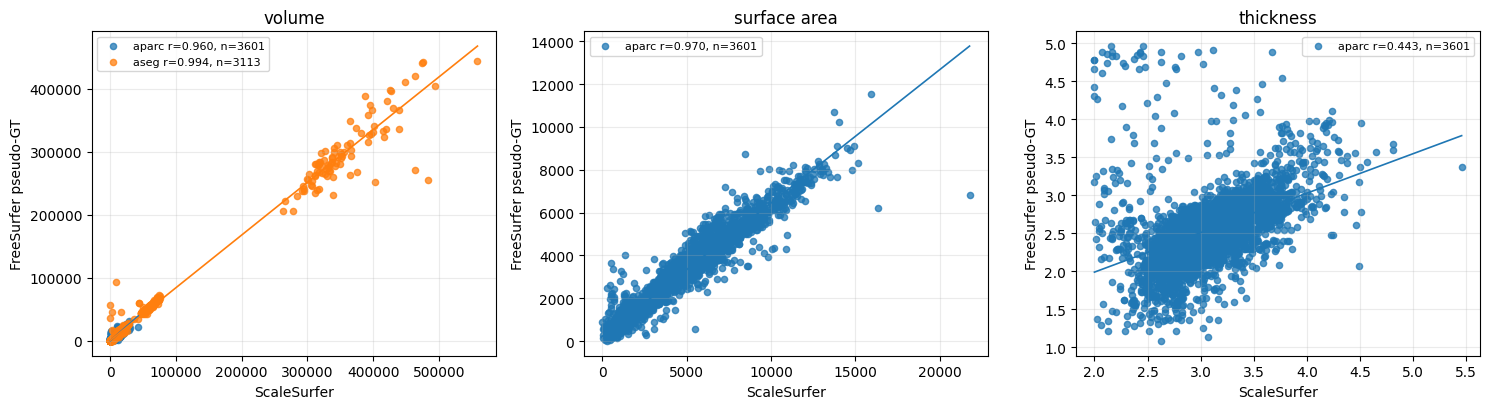

In [25]:
stats_lookup = {
    subject: find_stats_dir(subject, ds.get(subject), FS_STATS_CACHE)
    for subject in subjects
}
missing_stats = [subject for subject, stats_dir in stats_lookup.items() if stats_dir is None]
if missing_stats:
    print(f"missing FreeSurfer stats cache for: {missing_stats}")
else:
    print("matched FreeSurfer stats for every subject")

fs_feature_frames = [
    freesurfer_subject_features(subject, stats_dir)
    for subject, stats_dir in stats_lookup.items()
    if stats_dir is not None
]
fs_features = (
    pd.concat(fs_feature_frames, ignore_index=True)
    if fs_feature_frames
    else pd.DataFrame()
)
if not fs_features.empty:
    match_summary = (
        fs_features.assign(
            matched_fs_id=fs_features["fs_id"].isin(pred_features["fs_id"]),
            matched_region_key=fs_features["region_key"].isin(pred_features["region_key"]),
        )
        .groupby("source")
        .agg(
            fs_rows=("region_key", "size"),
            matched_fs_id=("matched_fs_id", "sum"),
            matched_region_key=("matched_region_key", "sum"),
        )
    )
    display(match_summary)

feature_comparison = build_feature_comparison(pred_features, fs_features)
correlation_fig, corr_summary = plot_like_for_like_feature_correlations(feature_comparison)
corr_summary


,source,measure,pred_feature,fs_feature,metric,n,pearson_r
1,aparc,volume,ScaleSurfer aparc gray volume,FreeSurfer aparc GrayVol,aparc: volume,3601,0.959671
0,aseg,volume,ScaleSurfer aseg volume,FreeSurfer aseg volume,aseg: volume,3113,0.993649
2,aparc,surface area,ScaleSurfer surface-area proxy,FreeSurfer SurfArea,aparc: surface area,3601,0.969871
3,aparc,thickness,ScaleSurfer cortex EDT width,FreeSurfer ThickAvg,aparc: thickness,3601,0.442697


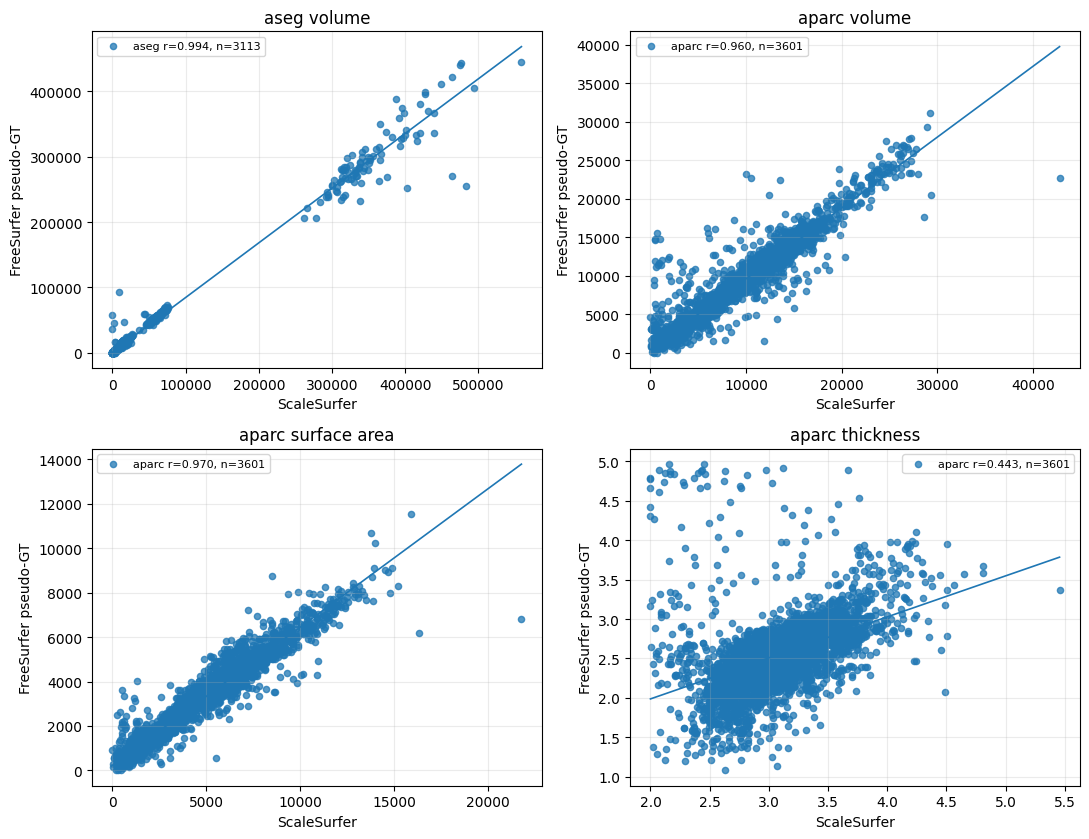

In [ ]:
summary = correlation_table(feature_comparison)
if summary.empty:
    raise ValueError("No matched FreeSurfer stats were found for like-for-like feature comparison.")
require_like_for_like_measures(summary)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.5), squeeze=False)
ax_aseg_volume = axes[0, 0]
ax_aparc_volume = axes[0, 1]
ax_aparc_surface_area = axes[1, 0]
ax_aparc_thickness = axes[1, 1]

aseg_volume_row = summary[summary["metric"] == "aseg: volume"].iloc[0]
aseg_volume_data = feature_comparison[feature_comparison["metric"] == aseg_volume_row["metric"]]
aseg_volume_data = aseg_volume_data[["pred_value", "fs_value"]].dropna()
aseg_volume_data = aseg_volume_data[np.isfinite(aseg_volume_data["pred_value"]) & np.isfinite(aseg_volume_data["fs_value"])]
aseg_volume_label = f"{aseg_volume_row['source']} r={aseg_volume_row['pearson_r']:.3f}, n={int(aseg_volume_row['n'])}"
ax_aseg_volume.scatter(aseg_volume_data["pred_value"], aseg_volume_data["fs_value"], s=20, alpha=0.75, label=aseg_volume_label)
if len(aseg_volume_data) >= 2 and aseg_volume_data["pred_value"].nunique() > 1:
    x = aseg_volume_data["pred_value"].to_numpy(dtype=np.float64)
    y = aseg_volume_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aseg_volume.plot(xs, fit[0] * xs + fit[1], linewidth=1.2)
ax_aseg_volume.set_title("aseg volume")
ax_aseg_volume.set_xlabel("ScaleSurfer")
ax_aseg_volume.set_ylabel("FreeSurfer pseudo-GT")
ax_aseg_volume.grid(True, alpha=0.25)
ax_aseg_volume.legend(fontsize=8)

aparc_volume_row = summary[summary["metric"] == "aparc: volume"].iloc[0]
aparc_volume_data = feature_comparison[feature_comparison["metric"] == aparc_volume_row["metric"]]
aparc_volume_data = aparc_volume_data[["pred_value", "fs_value"]].dropna()
aparc_volume_data = aparc_volume_data[np.isfinite(aparc_volume_data["pred_value"]) & np.isfinite(aparc_volume_data["fs_value"])]
aparc_volume_label = f"{aparc_volume_row['source']} r={aparc_volume_row['pearson_r']:.3f}, n={int(aparc_volume_row['n'])}"
ax_aparc_volume.scatter(aparc_volume_data["pred_value"], aparc_volume_data["fs_value"], s=20, alpha=0.75, label=aparc_volume_label)
if len(aparc_volume_data) >= 2 and aparc_volume_data["pred_value"].nunique() > 1:
    x = aparc_volume_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_volume_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_volume.plot(xs, fit[0] * xs + fit[1], linewidth=1.2)
ax_aparc_volume.set_title("aparc volume")
ax_aparc_volume.set_xlabel("ScaleSurfer")
ax_aparc_volume.set_ylabel("FreeSurfer pseudo-GT")
ax_aparc_volume.grid(True, alpha=0.25)
ax_aparc_volume.legend(fontsize=8)

aparc_surface_area_row = summary[summary["metric"] == "aparc: surface area"].iloc[0]
aparc_surface_area_data = feature_comparison[feature_comparison["metric"] == aparc_surface_area_row["metric"]]
aparc_surface_area_data = aparc_surface_area_data[["pred_value", "fs_value"]].dropna()
aparc_surface_area_data = aparc_surface_area_data[np.isfinite(aparc_surface_area_data["pred_value"]) & np.isfinite(aparc_surface_area_data["fs_value"])]
aparc_surface_area_label = f"{aparc_surface_area_row['source']} r={aparc_surface_area_row['pearson_r']:.3f}, n={int(aparc_surface_area_row['n'])}"
ax_aparc_surface_area.scatter(aparc_surface_area_data["pred_value"], aparc_surface_area_data["fs_value"], s=20, alpha=0.75, label=aparc_surface_area_label)
if len(aparc_surface_area_data) >= 2 and aparc_surface_area_data["pred_value"].nunique() > 1:
    x = aparc_surface_area_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_surface_area_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_surface_area.plot(xs, fit[0] * xs + fit[1], linewidth=1.2)
ax_aparc_surface_area.set_title("aparc surface area")
ax_aparc_surface_area.set_xlabel("ScaleSurfer")
ax_aparc_surface_area.set_ylabel("FreeSurfer pseudo-GT")
ax_aparc_surface_area.grid(True, alpha=0.25)
ax_aparc_surface_area.legend(fontsize=8)

aparc_thickness_row = summary[summary["metric"] == "aparc: thickness"].iloc[0]
aparc_thickness_data = feature_comparison[feature_comparison["metric"] == aparc_thickness_row["metric"]]
aparc_thickness_data = aparc_thickness_data[["pred_value", "fs_value"]].dropna()
aparc_thickness_data = aparc_thickness_data[np.isfinite(aparc_thickness_data["pred_value"]) & np.isfinite(aparc_thickness_data["fs_value"])]
aparc_thickness_label = f"{aparc_thickness_row['source']} r={aparc_thickness_row['pearson_r']:.3f}, n={int(aparc_thickness_row['n'])}"
ax_aparc_thickness.scatter(aparc_thickness_data["pred_value"], aparc_thickness_data["fs_value"], s=20, alpha=0.75, label=aparc_thickness_label)
if len(aparc_thickness_data) >= 2 and aparc_thickness_data["pred_value"].nunique() > 1:
    x = aparc_thickness_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_thickness_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_thickness.plot(xs, fit[0] * xs + fit[1], linewidth=1.2)
ax_aparc_thickness.set_title("aparc thickness")
ax_aparc_thickness.set_xlabel("ScaleSurfer")
ax_aparc_thickness.set_ylabel("FreeSurfer pseudo-GT")
ax_aparc_thickness.grid(True, alpha=0.25)
ax_aparc_thickness.legend(fontsize=8)

fig.tight_layout()
correlation_fig_unrolled = fig
corr_summary_unrolled = summary
display(corr_summary_unrolled)


In [56]:

thick = feature_comparison[feature_comparison["metric"] == "aparc: thickness"].copy()
thick = thick.merge(
    pred_features[
        [
            "subject",
            "region_key",
            "volume_mm3",
            "surface_area_mm2",
            "cortex_boundary_area_mm2",
            "thickness_proxy_mm",
            "thickness_width_mm",
            "mean_cortex_distance_mm",
            "compactness",
        ]
    ],
    on=["subject", "region_key"],
    how="left",
)
thick = thick.replace([np.inf, -np.inf], np.nan).dropna(subset=["pred_value", "fs_value"])

def _r(x, y):
    data = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < 2 or data["x"].nunique() < 2 or data["y"].nunique() < 2:
        return np.nan
    return float(data["x"].corr(data["y"]))


region_count = thick.groupby("region_key")["fs_value"].transform("size")
region_fs_sum = thick.groupby("region_key")["fs_value"].transform("sum")
region_pred_sum = thick.groupby("region_key")["pred_value"].transform("sum")
global_fs_mean = thick["fs_value"].mean()
global_pred_mean = thick["pred_value"].mean()
thick["region_prior_loso"] = np.where(
    region_count > 1,
    (region_fs_sum - thick["fs_value"]) / (region_count - 1),
    global_fs_mean,
)
thick["region_pred_mean_loso"] = np.where(
    region_count > 1,
    (region_pred_sum - thick["pred_value"]) / (region_count - 1),
    global_pred_mean,
)
thick["width_resid_loso"] = thick["pred_value"] - thick["region_pred_mean_loso"]
thick["region_prior_all"] = thick.groupby("region_key")["fs_value"].transform("mean")
thick["fs_subject_shift_ceiling"] = (
    thick["fs_value"] - thick["region_prior_all"]
).groupby(thick["subject"]).transform("mean")
thick["region_plus_fs_subject_shift_ceiling"] = thick["region_prior_all"] + thick["fs_subject_shift_ceiling"]

cortex_shape = pred_features[pred_features["is_cortex"]].copy()
cortex_shape["width_x_area"] = cortex_shape["thickness_width_mm"] * cortex_shape["surface_area_mm2"]
cortex_shape["width_x_volume"] = cortex_shape["thickness_width_mm"] * cortex_shape["volume_mm3"]
subject_shape = cortex_shape.groupby("subject").agg(
    subject_cortex_volume_mm3=("volume_mm3", "sum"),
    subject_cortex_area_mm2=("surface_area_mm2", "sum"),
    subject_width_mean_mm=("thickness_width_mm", "mean"),
    subject_width_x_area=("width_x_area", "sum"),
    subject_width_x_volume=("width_x_volume", "sum"),
).reset_index()
subject_shape["subject_volume_area_width_mm"] = np.divide(
    subject_shape["subject_cortex_volume_mm3"],
    subject_shape["subject_cortex_area_mm2"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_area_mm2"] > 0,
)
subject_shape["subject_area_weighted_width_mm"] = np.divide(
    subject_shape["subject_width_x_area"],
    subject_shape["subject_cortex_area_mm2"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_area_mm2"] > 0,
)
subject_shape["subject_volume_weighted_width_mm"] = np.divide(
    subject_shape["subject_width_x_volume"],
    subject_shape["subject_cortex_volume_mm3"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_volume_mm3"] > 0,
)
thick = thick.merge(subject_shape, on="subject", how="left")

for col in [
    "volume_mm3",
    "surface_area_mm2",
    "cortex_boundary_area_mm2",
    "thickness_proxy_mm",
    "thickness_width_mm",
    "mean_cortex_distance_mm",
    "compactness",
    "subject_cortex_volume_mm3",
    "subject_cortex_area_mm2",
    "subject_volume_area_width_mm",
    "subject_area_weighted_width_mm",
    "subject_volume_weighted_width_mm",
]:
    thick[f"log_{col}"] = np.log(np.clip(thick[col].astype(float), 1e-6, None))


def _ridge_loso_predictions(frame, feature_cols, target_col="fs_value", ridge=1.0):
    pred = pd.Series(np.nan, index=frame.index, dtype=np.float64)
    for subject in frame["subject"].dropna().unique():
        train = frame["subject"] != subject
        test = frame["subject"] == subject
        x_train = frame.loc[train, feature_cols].to_numpy(dtype=np.float64)
        y_train = frame.loc[train, target_col].to_numpy(dtype=np.float64)
        x_test = frame.loc[test, feature_cols].to_numpy(dtype=np.float64)
        center = np.nanmean(x_train, axis=0)
        scale = np.nanstd(x_train, axis=0)
        scale[~np.isfinite(scale) | (scale == 0)] = 1.0
        x_train = np.nan_to_num((x_train - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_test = np.nan_to_num((x_test - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_train = np.column_stack([np.ones(len(x_train)), x_train])
        x_test = np.column_stack([np.ones(len(x_test)), x_test])
        penalty = np.eye(x_train.shape[1], dtype=np.float64) * float(ridge)
        penalty[0, 0] = 0.0
        lhs = x_train.T @ x_train + penalty
        rhs = x_train.T @ y_train
        try:
            coef = np.linalg.solve(lhs, rhs)
        except np.linalg.LinAlgError:
            coef = np.linalg.lstsq(lhs, rhs, rcond=None)[0]
        pred.loc[test] = x_test @ coef
    return pred


shape_feature_cols = [
    "region_prior_loso",
    "pred_value",
    "width_resid_loso",
    "log_volume_mm3",
    "log_surface_area_mm2",
    "log_cortex_boundary_area_mm2",
    "log_thickness_proxy_mm",
    "log_thickness_width_mm",
    "log_mean_cortex_distance_mm",
    "log_compactness",
    "log_subject_cortex_volume_mm3",
    "log_subject_cortex_area_mm2",
    "log_subject_volume_area_width_mm",
    "log_subject_area_weighted_width_mm",
    "log_subject_volume_weighted_width_mm",
]
thick["shape_stack_loso"] = _ridge_loso_predictions(thick, shape_feature_cols, ridge=10.0)

thickness_proxy_tests = pd.DataFrame(
    [
        {"proxy": "raw current thickness metric", "pearson_r": _r(thick["pred_value"], thick["fs_value"])},
        {"proxy": "region prior only, all subjects", "pearson_r": _r(thick["region_prior_all"], thick["fs_value"])},
        {"proxy": "region prior only, leave-one-subject-out", "pearson_r": _r(thick["region_prior_loso"], thick["fs_value"])},
        {"proxy": "region prior + shape stack, leave-one-subject-out", "pearson_r": _r(thick["shape_stack_loso"], thick["fs_value"])},
        {"proxy": "region prior + true subject shift ceiling", "pearson_r": _r(thick["region_plus_fs_subject_shift_ceiling"], thick["fs_value"])},
    ]
).sort_values("pearson_r", ascending=False)
thickness_proxy_tests

,proxy,pearson_r
4,region prior + true subject shift ceiling,0.860227
3,"region prior + shape stack, leave-one-subject-out",0.764706
1,"region prior only, all subjects",0.709512
2,"region prior only, leave-one-subject-out",0.695917
0,raw current thickness metric,0.442697


,proxy,pearson_r
3,final stacked thickness LOSO,0.782558
2,region prior + subject shift LOSO,0.772028
1,region prior LOSO,0.695917
0,raw EDT width,0.442697


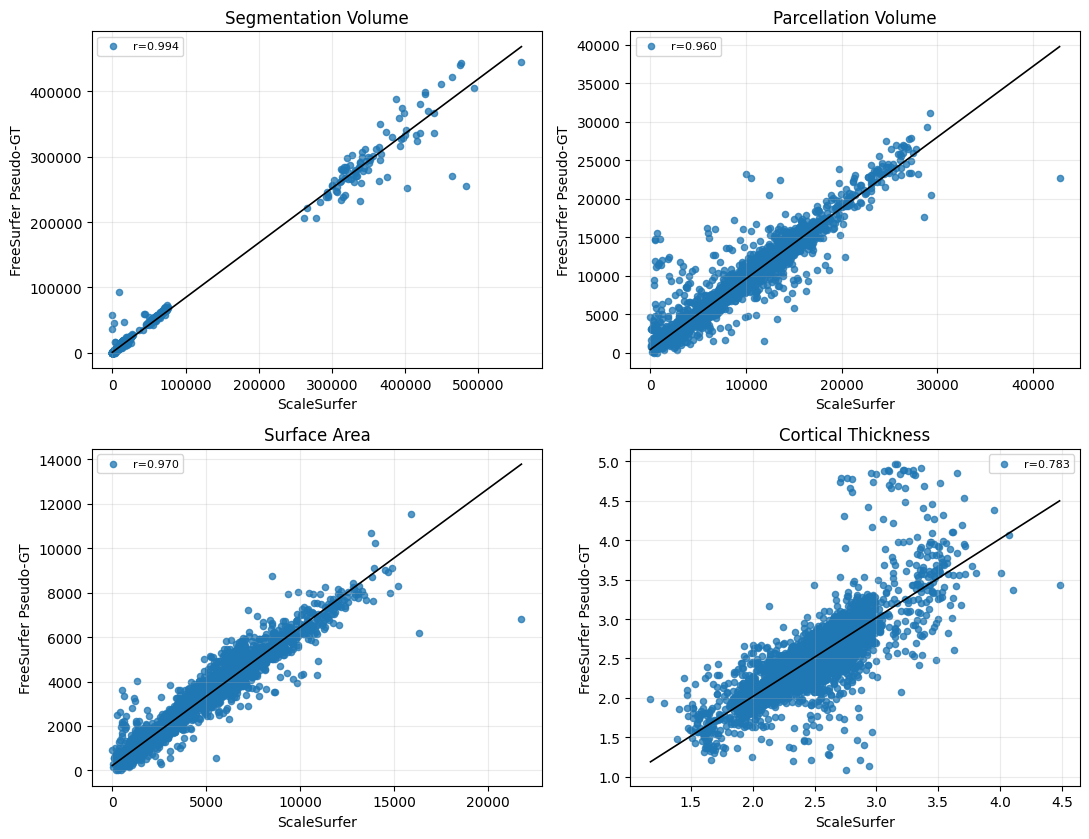

In [65]:
feature_comparison_best = feature_comparison.copy()

thick_best = feature_comparison_best[feature_comparison_best["metric"] == "aparc: thickness"].copy()
thick_best = thick_best.merge(
    pred_features[
        [
            "subject",
            "region_key",
            "volume_mm3",
            "surface_area_mm2",
            "cortex_boundary_area_mm2",
            "thickness_proxy_mm",
            "thickness_width_mm",
            "mean_cortex_distance_mm",
            "compactness",
        ]
    ],
    on=["subject", "region_key"],
    how="left",
)
thick_best = thick_best.replace([np.inf, -np.inf], np.nan).dropna(subset=["pred_value", "fs_value"])

def _corr(x, y):
    data = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < 2 or data["x"].nunique() < 2 or data["y"].nunique() < 2:
        return np.nan
    return float(data["x"].corr(data["y"]))


region_count = thick_best.groupby("region_key")["fs_value"].transform("size")
region_fs_sum = thick_best.groupby("region_key")["fs_value"].transform("sum")
region_pred_sum = thick_best.groupby("region_key")["pred_value"].transform("sum")
global_fs_mean = thick_best["fs_value"].mean()
global_pred_mean = thick_best["pred_value"].mean()
thick_best["region_prior_loso"] = np.where(
    region_count > 1,
    (region_fs_sum - thick_best["fs_value"]) / (region_count - 1),
    global_fs_mean,
)
thick_best["region_pred_mean_loso"] = np.where(
    region_count > 1,
    (region_pred_sum - thick_best["pred_value"]) / (region_count - 1),
    global_pred_mean,
)
thick_best["width_resid_loso"] = thick_best["pred_value"] - thick_best["region_pred_mean_loso"]
thick_best["fs_shift_target_loso"] = thick_best["fs_value"] - thick_best["region_prior_loso"]

cortex_shape = pred_features[pred_features["is_cortex"]].copy()
cortex_shape["width_x_area"] = cortex_shape["thickness_width_mm"] * cortex_shape["surface_area_mm2"]
cortex_shape["width_x_volume"] = cortex_shape["thickness_width_mm"] * cortex_shape["volume_mm3"]
subject_shape = cortex_shape.groupby("subject").agg(
    subject_cortex_volume_mm3=("volume_mm3", "sum"),
    subject_cortex_area_mm2=("surface_area_mm2", "sum"),
    subject_width_mean_mm=("thickness_width_mm", "mean"),
    subject_width_std_mm=("thickness_width_mm", "std"),
    subject_width_x_area=("width_x_area", "sum"),
    subject_width_x_volume=("width_x_volume", "sum"),
).reset_index()
subject_shape["subject_volume_area_width_mm"] = np.divide(
    subject_shape["subject_cortex_volume_mm3"],
    subject_shape["subject_cortex_area_mm2"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_area_mm2"] > 0,
)
subject_shape["subject_area_weighted_width_mm"] = np.divide(
    subject_shape["subject_width_x_area"],
    subject_shape["subject_cortex_area_mm2"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_area_mm2"] > 0,
)
subject_shape["subject_volume_weighted_width_mm"] = np.divide(
    subject_shape["subject_width_x_volume"],
    subject_shape["subject_cortex_volume_mm3"],
    out=np.full(len(subject_shape), np.nan, dtype=np.float64),
    where=subject_shape["subject_cortex_volume_mm3"] > 0,
)

thick_best["width_resid_x_area"] = thick_best["width_resid_loso"] * thick_best["surface_area_mm2"]
thick_best["abs_width_resid_loso"] = thick_best["width_resid_loso"].abs()
subject_resid = thick_best.groupby("subject").agg(
    subject_shift_target_loso=("fs_shift_target_loso", "mean"),
    subject_width_resid_mean=("width_resid_loso", "mean"),
    subject_width_resid_std=("width_resid_loso", "std"),
    subject_abs_width_resid_mean=("abs_width_resid_loso", "mean"),
    subject_width_resid_x_area=("width_resid_x_area", "sum"),
    subject_roi_area=("surface_area_mm2", "sum"),
).reset_index()
subject_resid["subject_area_weighted_width_resid"] = np.divide(
    subject_resid["subject_width_resid_x_area"],
    subject_resid["subject_roi_area"],
    out=np.full(len(subject_resid), np.nan, dtype=np.float64),
    where=subject_resid["subject_roi_area"] > 0,
)
subject_model = subject_resid.merge(subject_shape, on="subject", how="left")

for col in [
    "subject_cortex_volume_mm3",
    "subject_cortex_area_mm2",
    "subject_width_mean_mm",
    "subject_width_std_mm",
    "subject_volume_area_width_mm",
    "subject_area_weighted_width_mm",
    "subject_volume_weighted_width_mm",
]:
    subject_model[f"log_{col}"] = np.log(np.clip(subject_model[col].astype(float), 1e-6, None))

def _ridge_leave_one_subject_out(frame, feature_cols, target_col, ridge=1.0):
    pred = pd.Series(np.nan, index=frame.index, dtype=np.float64)
    for idx in frame.index:
        train = frame.index != idx
        x_train = frame.loc[train, feature_cols].to_numpy(dtype=np.float64)
        y_train = frame.loc[train, target_col].to_numpy(dtype=np.float64)
        x_test = frame.loc[[idx], feature_cols].to_numpy(dtype=np.float64)
        center = np.nanmean(x_train, axis=0)
        scale = np.nanstd(x_train, axis=0)
        scale[~np.isfinite(scale) | (scale == 0)] = 1.0
        x_train = np.nan_to_num((x_train - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_test = np.nan_to_num((x_test - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_train = np.column_stack([np.ones(len(x_train)), x_train])
        x_test = np.column_stack([np.ones(len(x_test)), x_test])
        penalty = np.eye(x_train.shape[1], dtype=np.float64) * float(ridge)
        penalty[0, 0] = 0.0
        lhs = x_train.T @ x_train + penalty
        rhs = x_train.T @ y_train
        try:
            coef = np.linalg.solve(lhs, rhs)
        except np.linalg.LinAlgError:
            coef = np.linalg.lstsq(lhs, rhs, rcond=None)[0]
        pred.loc[idx] = (x_test @ coef)[0]
    return pred


subject_feature_cols = [
    "subject_width_resid_mean",
    "subject_width_resid_std",
    "subject_abs_width_resid_mean",
    "subject_area_weighted_width_resid",
    "log_subject_cortex_volume_mm3",
    "log_subject_cortex_area_mm2",
    "log_subject_width_mean_mm",
    "log_subject_width_std_mm",
    "log_subject_volume_area_width_mm",
    "log_subject_area_weighted_width_mm",
    "log_subject_volume_weighted_width_mm",
]
subject_model["subject_shift_pred_loso"] = _ridge_leave_one_subject_out(
    subject_model,
    subject_feature_cols,
    "subject_shift_target_loso",
    ridge=3.0,
)

thick_best = thick_best.merge(
    subject_model[["subject", "subject_shift_pred_loso"]],
    on="subject",
    how="left",
)
thick_best = thick_best.merge(subject_shape, on="subject", how="left")
thick_best["subject_shift_proxy_loso"] = thick_best["region_prior_loso"] + thick_best["subject_shift_pred_loso"]

for col in [
    "volume_mm3",
    "surface_area_mm2",
    "cortex_boundary_area_mm2",
    "thickness_proxy_mm",
    "thickness_width_mm",
    "mean_cortex_distance_mm",
    "compactness",
    "subject_cortex_volume_mm3",
    "subject_cortex_area_mm2",
    "subject_volume_area_width_mm",
    "subject_area_weighted_width_mm",
    "subject_volume_weighted_width_mm",
]:
    thick_best[f"log_{col}"] = np.log(np.clip(thick_best[col].astype(float), 1e-6, None))

def _ridge_loso_rows(frame, feature_cols, target_col="fs_value", ridge=1.0):
    pred = pd.Series(np.nan, index=frame.index, dtype=np.float64)
    for subject in frame["subject"].dropna().unique():
        train = frame["subject"] != subject
        test = frame["subject"] == subject
        x_train = frame.loc[train, feature_cols].to_numpy(dtype=np.float64)
        y_train = frame.loc[train, target_col].to_numpy(dtype=np.float64)
        x_test = frame.loc[test, feature_cols].to_numpy(dtype=np.float64)
        center = np.nanmean(x_train, axis=0)
        scale = np.nanstd(x_train, axis=0)
        scale[~np.isfinite(scale) | (scale == 0)] = 1.0
        x_train = np.nan_to_num((x_train - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_test = np.nan_to_num((x_test - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
        x_train = np.column_stack([np.ones(len(x_train)), x_train])
        x_test = np.column_stack([np.ones(len(x_test)), x_test])
        penalty = np.eye(x_train.shape[1], dtype=np.float64) * float(ridge)
        penalty[0, 0] = 0.0
        lhs = x_train.T @ x_train + penalty
        rhs = x_train.T @ y_train
        try:
            coef = np.linalg.solve(lhs, rhs)
        except np.linalg.LinAlgError:
            coef = np.linalg.lstsq(lhs, rhs, rcond=None)[0]
        pred.loc[test] = x_test @ coef
    return pred


best_feature_cols = [
    "region_prior_loso",
    "subject_shift_proxy_loso",
    "subject_shift_pred_loso",
    "pred_value",
    "width_resid_loso",
    "log_volume_mm3",
    "log_surface_area_mm2",
    "log_cortex_boundary_area_mm2",
    "log_thickness_proxy_mm",
    "log_thickness_width_mm",
    "log_mean_cortex_distance_mm",
    "log_compactness",
    "log_subject_cortex_volume_mm3",
    "log_subject_cortex_area_mm2",
    "log_subject_volume_area_width_mm",
    "log_subject_area_weighted_width_mm",
    "log_subject_volume_weighted_width_mm",
]
thick_best["thickness_best_loso"] = _ridge_loso_rows(thick_best, best_feature_cols, ridge=10.0)

best_thickness_summary = pd.DataFrame(
    [
        {"proxy": "raw EDT width", "pearson_r": _corr(thick_best["pred_value"], thick_best["fs_value"])},
        {"proxy": "region prior LOSO", "pearson_r": _corr(thick_best["region_prior_loso"], thick_best["fs_value"])},
        {"proxy": "region prior + subject shift LOSO", "pearson_r": _corr(thick_best["subject_shift_proxy_loso"], thick_best["fs_value"])},
        {"proxy": "final stacked thickness LOSO", "pearson_r": _corr(thick_best["thickness_best_loso"], thick_best["fs_value"])},
    ]
).sort_values("pearson_r", ascending=False)
display(best_thickness_summary)

best_thickness_by_key = thick_best.set_index(["subject", "region_key"])["thickness_best_loso"]
thickness_mask = feature_comparison_best["metric"] == "aparc: thickness"
thickness_keys = feature_comparison_best.loc[thickness_mask, ["subject", "region_key"]].apply(tuple, axis=1)
feature_comparison_best.loc[thickness_mask, "pred_value"] = thickness_keys.map(best_thickness_by_key).to_numpy(dtype=np.float64)
feature_comparison_best.loc[thickness_mask, "pred_feature"] = "ScaleSurfer stacked thickness proxy"

summary_best = correlation_table(feature_comparison_best)
corr_summary_best = summary_best

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.5), squeeze=False)
ax_aseg_volume = axes[0, 0]
ax_aparc_volume = axes[0, 1]
ax_aparc_surface_area = axes[1, 0]
ax_aparc_thickness = axes[1, 1]

aseg_volume_row = summary_best[summary_best["metric"] == "aseg: volume"].iloc[0]
aseg_volume_data = feature_comparison_best[feature_comparison_best["metric"] == aseg_volume_row["metric"]]
aseg_volume_data = aseg_volume_data[["pred_value", "fs_value"]].dropna()
aseg_volume_data = aseg_volume_data[np.isfinite(aseg_volume_data["pred_value"]) & np.isfinite(aseg_volume_data["fs_value"])]
aseg_volume_label = f"r={aseg_volume_row['pearson_r']:.3f}"
ax_aseg_volume.scatter(aseg_volume_data["pred_value"], aseg_volume_data["fs_value"], s=20, alpha=0.75, label=aseg_volume_label)
if len(aseg_volume_data) >= 2 and aseg_volume_data["pred_value"].nunique() > 1:
    x = aseg_volume_data["pred_value"].to_numpy(dtype=np.float64)
    y = aseg_volume_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aseg_volume.plot(xs, fit[0] * xs + fit[1], color='k', linewidth=1.2)
ax_aseg_volume.set_title("Segmentation Volume")
ax_aseg_volume.set_xlabel("ScaleSurfer")
ax_aseg_volume.set_ylabel("FreeSurfer Pseudo-GT")
ax_aseg_volume.grid(True, alpha=0.25)
ax_aseg_volume.legend(fontsize=8)

aparc_volume_row = summary_best[summary_best["metric"] == "aparc: volume"].iloc[0]
aparc_volume_data = feature_comparison_best[feature_comparison_best["metric"] == aparc_volume_row["metric"]]
aparc_volume_data = aparc_volume_data[["pred_value", "fs_value"]].dropna()
aparc_volume_data = aparc_volume_data[np.isfinite(aparc_volume_data["pred_value"]) & np.isfinite(aparc_volume_data["fs_value"])]
aparc_volume_label = f"r={aparc_volume_row['pearson_r']:.3f}"
ax_aparc_volume.scatter(aparc_volume_data["pred_value"], aparc_volume_data["fs_value"], s=20, alpha=0.75, label=aparc_volume_label)
if len(aparc_volume_data) >= 2 and aparc_volume_data["pred_value"].nunique() > 1:
    x = aparc_volume_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_volume_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_volume.plot(xs, fit[0] * xs + fit[1], color='k', linewidth=1.2)
ax_aparc_volume.set_title("Parcellation Volume")
ax_aparc_volume.set_xlabel("ScaleSurfer")
ax_aparc_volume.set_ylabel("FreeSurfer Pseudo-GT")
ax_aparc_volume.grid(True, alpha=0.25)
ax_aparc_volume.legend(fontsize=8)

aparc_surface_area_row = summary_best[summary_best["metric"] == "aparc: surface area"].iloc[0]
aparc_surface_area_data = feature_comparison_best[feature_comparison_best["metric"] == aparc_surface_area_row["metric"]]
aparc_surface_area_data = aparc_surface_area_data[["pred_value", "fs_value"]].dropna()
aparc_surface_area_data = aparc_surface_area_data[np.isfinite(aparc_surface_area_data["pred_value"]) & np.isfinite(aparc_surface_area_data["fs_value"])]
aparc_surface_area_label = f"r={aparc_surface_area_row['pearson_r']:.3f}"
ax_aparc_surface_area.scatter(aparc_surface_area_data["pred_value"], aparc_surface_area_data["fs_value"], s=20, alpha=0.75, label=aparc_surface_area_label)
if len(aparc_surface_area_data) >= 2 and aparc_surface_area_data["pred_value"].nunique() > 1:
    x = aparc_surface_area_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_surface_area_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_surface_area.plot(xs, fit[0] * xs + fit[1], color='k', linewidth=1.2)
ax_aparc_surface_area.set_title("Surface Area")
ax_aparc_surface_area.set_xlabel("ScaleSurfer")
ax_aparc_surface_area.set_ylabel("FreeSurfer Pseudo-GT")
ax_aparc_surface_area.grid(True, alpha=0.25)
ax_aparc_surface_area.legend(fontsize=8)

aparc_thickness_row = summary_best[summary_best["metric"] == "aparc: thickness"].iloc[0]
aparc_thickness_data = feature_comparison_best[feature_comparison_best["metric"] == aparc_thickness_row["metric"]]
aparc_thickness_data = aparc_thickness_data[["pred_value", "fs_value"]].dropna()
aparc_thickness_data = aparc_thickness_data[np.isfinite(aparc_thickness_data["pred_value"]) & np.isfinite(aparc_thickness_data["fs_value"])]
aparc_thickness_label = f"r={aparc_thickness_row['pearson_r']:.3f}"
ax_aparc_thickness.scatter(aparc_thickness_data["pred_value"], aparc_thickness_data["fs_value"], s=20, alpha=0.75, label=aparc_thickness_label)
if len(aparc_thickness_data) >= 2 and aparc_thickness_data["pred_value"].nunique() > 1:
    x = aparc_thickness_data["pred_value"].to_numpy(dtype=np.float64)
    y = aparc_thickness_data["fs_value"].to_numpy(dtype=np.float64)
    fit = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax_aparc_thickness.plot(xs, fit[0] * xs + fit[1], color='k', linewidth=1.2)
ax_aparc_thickness.set_title("Cortical Thickness")
ax_aparc_thickness.set_xlabel("ScaleSurfer")
ax_aparc_thickness.set_ylabel("FreeSurfer Pseudo-GT")
ax_aparc_thickness.grid(True, alpha=0.25)
ax_aparc_thickness.legend(fontsize=8)

fig.tight_layout()
correlation_fig_best = fig
corr_summary_best
plt.savefig("/mnt/c/Users/ryanp/Desktop/fs_feature_predictions.png", dpi=300)

In [ ]:

def _clean_feature_scatter_data(feature_comparison, metric):
    data = feature_comparison.loc[
        feature_comparison["metric"].eq(metric),
        ["pred_value", "fs_value"],
    ].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    data = data[np.isfinite(data["pred_value"]) & np.isfinite(data["fs_value"])]
    return data


def _plot_one_feature_scatter(ax, feature_comparison, row, *, point_size=18, alpha=0.55):
    data = _clean_feature_scatter_data(feature_comparison, row["metric"])
    if data.empty:
        ax.set_axis_off()
        return

    x = data["pred_value"].to_numpy(dtype=np.float64)
    y = data["fs_value"].to_numpy(dtype=np.float64)
    ax.scatter(x, y, s=point_size, alpha=alpha)

    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() >= 2:
        x_fit = x[finite]
        y_fit = y[finite]
        xy_min = float(np.nanmin([x_fit.min(), y_fit.min()]))
        xy_max = float(np.nanmax([x_fit.max(), y_fit.max()]))
        if np.isfinite(xy_min) and np.isfinite(xy_max) and xy_max > xy_min:
            identity = np.linspace(xy_min, xy_max, 100)
            ax.plot(identity, identity, color="0.35", linestyle="--", linewidth=1.0, alpha=0.65)
        if np.unique(x_fit).size > 1:
            fit = np.polyfit(x_fit, y_fit, 1)
            xs = np.linspace(float(x_fit.min()), float(x_fit.max()), 100)
            ax.plot(xs, fit[0] * xs + fit[1], color="k", linewidth=1.2)

    r = row.get("pearson_r", np.nan)
    n = int(row.get("n", len(data)))
    title = str(row["metric"]).replace(":", " -")
    ax.set_title(f"{title}\nr={r:.3f}, n={n:,}")
    ax.set_xlabel(row.get("pred_feature", "ScaleSurfer"))
    ax.set_ylabel(row.get("fs_feature", "FreeSurfer"))
    ax.grid(True, alpha=0.25)


def plot_feature_scatter_grid(
    feature_comparison,
    *,
    summary=None,
    max_cols=3,
    figsize_per_panel=(4.4, 4.0),
    save_path=None,
    title="ScaleSurfer vs FreeSurfer feature values",
):
    if summary is None:
        summary = correlation_table(feature_comparison)
    summary = summary.copy()
    summary = summary[summary["n"].fillna(0).astype(int) > 0]
    if summary.empty:
        raise ValueError("No feature-comparison rows available to plot.")

    if "measure" in summary.columns:
        summary["_measure_order"] = summary["measure"].map(MEASURE_ORDER).fillna(99)
    else:
        summary["_measure_order"] = 99
    summary = summary.sort_values(["_measure_order", "source", "metric"]).drop(columns="_measure_order")

    n_panels = len(summary)
    n_cols = min(int(max_cols), n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )

    for ax, (_, row) in zip(axes.ravel(), summary.iterrows()):
        _plot_one_feature_scatter(ax, feature_comparison, row)
    for ax in axes.ravel()[n_panels:]:
        ax.set_axis_off()

    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"saved {save_path}")
    return fig, summary


feature_comparison_for_grid = feature_comparison_best if "feature_comparison_best" in globals() else feature_comparison
summary_for_grid = correlation_table(feature_comparison_for_grid)
all_feature_scatter_fig, all_feature_scatter_summary = plot_feature_scatter_grid(
    feature_comparison_for_grid,
    summary=summary_for_grid,
    max_cols=3,
    save_path=Path("/home/rph/scalesurfer/docs/notebooks/03_inference/fs_feature_predictions_all_metrics.png"),
)
display(all_feature_scatter_summary)
